# 🩺 Diabetes Onset Prediction — Machine Learning Project
**BSCS 8th Semester | Machine Learning Lab | Final Term Project**  
**Team Members:** Waseem Ahmad & Wisal Ahmad  
**Instructor:** Saim Sanan  
**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)

---

## Project Overview
This notebook covers the complete ML workflow to predict whether a patient is likely to develop diabetes based on diagnostic measurements.

**Steps Covered:**
1. Import Libraries
2. Load & Explore Dataset
3. Data Preprocessing
4. Feature Engineering & Selection
5. Train-Test Split & Feature Scaling
6. Model 1 — Logistic Regression
7. Model 2 — Random Forest
8. Model Comparison
9. Visualizations
10. Conclusion

## Import Libraries

We import all necessary Python libraries before starting. This includes:
- **pandas / numpy** → data loading and manipulation
- **matplotlib / seaborn** → data visualization
- **sklearn** → machine learning models and evaluation

In [ ]:
# ─── Data Handling ───────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── ML: Preprocessing ───────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ─── ML: Models ──────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ─── ML: Evaluation ──────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ─── Display Settings ────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Load & Explore the Dataset

We load the dataset from a CSV file and perform initial **Exploratory Data Analysis (EDA)**.

> 📥 Download the dataset from:  
> https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  
> Save it as `diabetes.csv` in the same folder as this notebook.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load dataset correctly
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/pima-indians-diabetes-database",
    "diabetes.csv"   # specify file name
)
print("Dataset loaded successfully!")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset loaded successfully!


In [ ]:
# ─── Load Dataset ────────────────────────────────────────────

print("Dataset Shape:", df.shape)
print("   → Rows:", df.shape[0], "| Columns:", df.shape[1])
print()
print("Column Names:")
print(df.columns.tolist())

Dataset Shape: (768, 9)
   → Rows: 768 | Columns: 9

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# ─── Preview First 5 Rows ────────────────────────────────────
# This shows us what the data looks like
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# ─── Basic Statistics ────────────────────────────────────────
# Shows count, mean, min, max, std for each column
# Look for suspicious values like 0 in Glucose, BMI, etc.
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# ─── Data Types & Missing Values ────────────────────────────
print("Data Types:")
print(df.dtypes)
print()
print("Missing (NaN) Values per Column:")
print(df.isnull().sum())

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing (NaN) Values per Column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# ─── Class Distribution ──────────────────────────────────────
# Check how many diabetic (1) vs non-diabetic (0) patients exist
print("Target Variable (Outcome) Distribution:")
print(df['Outcome'].value_counts())
print()
print("📊 Percentage:")
print(df['Outcome'].value_counts(normalize=True) * 100)

Target Variable (Outcome) Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

📊 Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## Data Preprocessing

This is the most important step in any ML project.

**Problems we need to fix:**
- Columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` contain **0 values** which are biologically impossible (you can't have 0 glucose and be alive!)
- These 0s are actually **missing values** that were entered as 0 in the original dataset
- We will replace them with the **median** value of each column (median is better than mean because it's not affected by outliers)

In [ ]:
# ─── Identify Invalid Zero Values ────────────────────────────
# These columns CANNOT logically be zero
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Count of ZERO values in biologically invalid columns:")
for col in zero_not_allowed:
    zero_count = (df[col] == 0).sum()
    print(f"   {col}: {zero_count} zeros ({zero_count/len(df)*100:.1f}%)")

Count of ZERO values in biologically invalid columns:
   Glucose: 5 zeros (0.7%)
   BloodPressure: 35 zeros (4.6%)
   SkinThickness: 227 zeros (29.6%)
   Insulin: 374 zeros (48.7%)
   BMI: 11 zeros (1.4%)


In [ ]:
# ─── Replace Zeros with Median ───────────────────────────────
# We use MEDIAN (not mean) because it's more robust to outliers

for col in zero_not_allowed:
    median_val = df[col].median()              # Calculate median (ignoring zeros)
    df[col] = df[col].replace(0, median_val)   # Replace all 0s with the median
    print(f"{col}: Replaced 0s with median = {median_val:.2f}")

Glucose: Replaced 0s with median = 117.00
BloodPressure: Replaced 0s with median = 72.00
SkinThickness: Replaced 0s with median = 23.00
Insulin: Replaced 0s with median = 30.50
BMI: Replaced 0s with median = 32.00


In [ ]:
# ─── Check for Duplicate Rows ────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found!")

Duplicate rows found: 0
No duplicates found!


In [ ]:
# ─── Verify Cleaned Data ─────────────────────────────────────
print("Data after preprocessing:")
df.describe()

Data after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Feature Engineering & Visualization

Before training models, we explore the relationships between features to understand:
- Which features are most correlated with the target (Outcome)?
- Are any features highly correlated with each other (multicollinearity)?

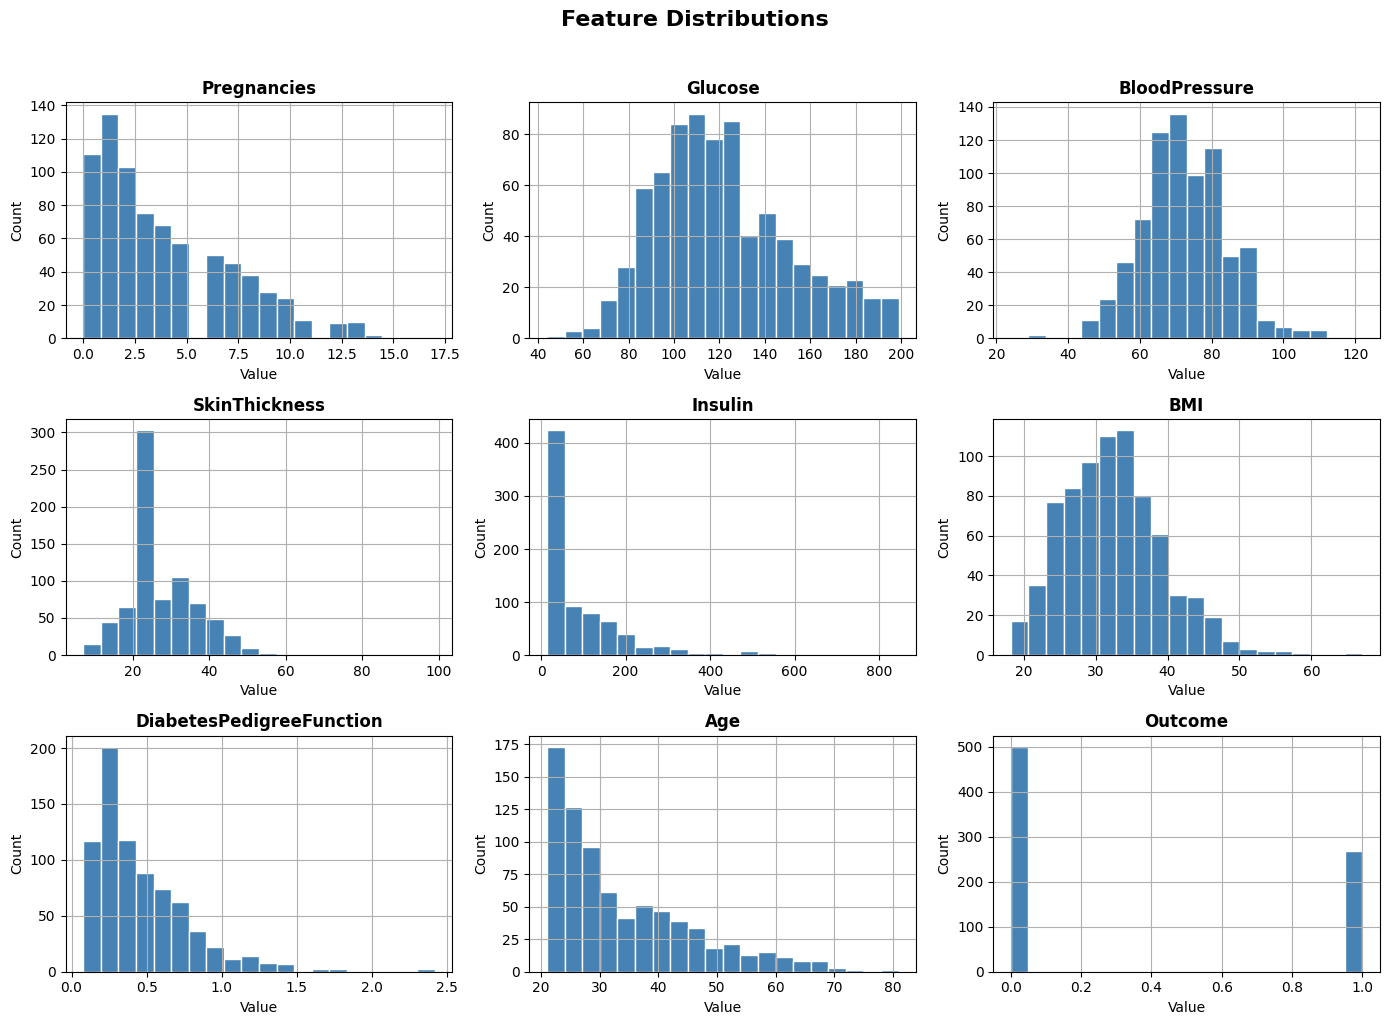

Distribution plot!


In [ ]:
# ─── Plot 1: Distribution of Each Feature ────────────────────
# Histograms show the spread and shape of each variable

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)

features = df.columns.tolist()
for i, feature in enumerate(features):
    ax = axes[i // 3][i % 3]
    df[feature].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plot!")

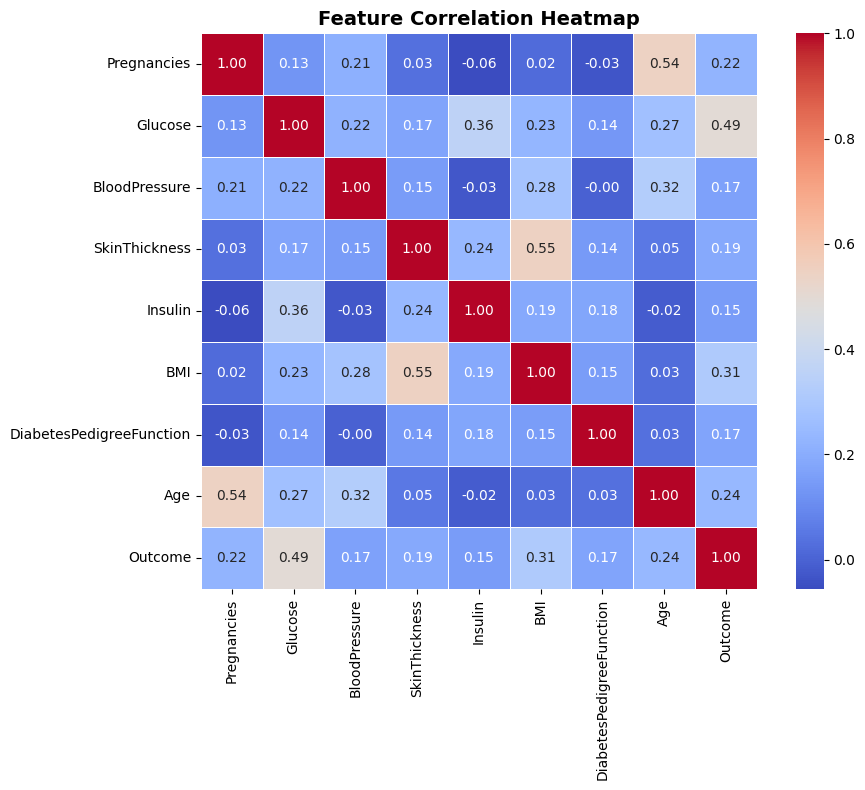


Correlation with Outcome (Target):
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin                     0.148457
Name: Outcome, dtype: float64


In [ ]:
# ─── Plot 2: Correlation Heatmap ─────────────────────────────
# Shows how strongly each feature is correlated with others
# Values close to 1 or -1 indicate strong correlation
# We want high correlation with 'Outcome' but low between features

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation numbers
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # Color: blue=negative, red=positive
    linewidths=0.5,
    square=True
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Show correlation with Outcome specifically
print("\nCorrelation with Outcome (Target):")
print(corr_matrix['Outcome'].sort_values(ascending=False))

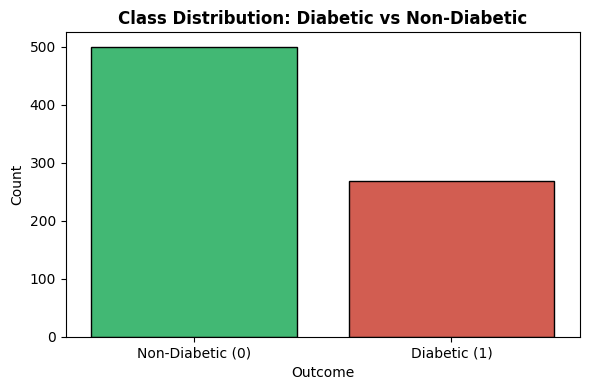

In [ ]:
# ─── Plot 3: Outcome Count Plot ──────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(
    x='Outcome', data=df,
    palette=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
plt.title('Class Distribution: Diabetic vs Non-Diabetic', fontweight='bold')
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

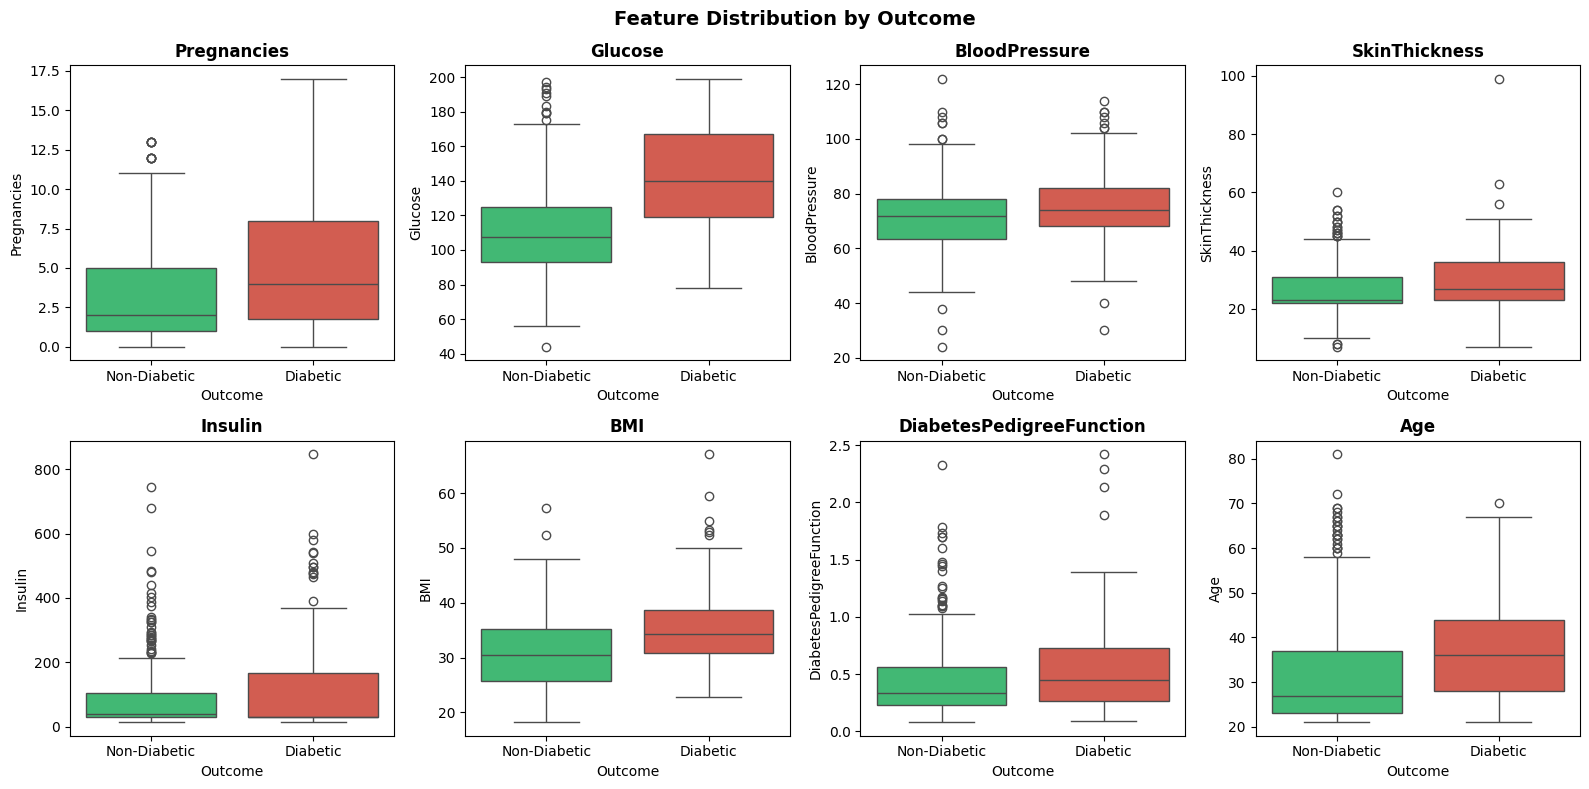

Boxplot!


In [ ]:
# ─── Plot 4: Boxplots — Feature vs Outcome ───────────────────
# Shows how each feature differs between diabetic and non-diabetic patients

feature_cols = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distribution by Outcome', fontsize=14, fontweight='bold')

for i, col in enumerate(feature_cols):
    ax = axes[i // 4][i % 4]
    sns.boxplot(
        x='Outcome', y=col, data=df,
        palette=['#2ecc71', '#e74c3c'], ax=ax
    )
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.savefig('plot_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplot!")

## Train-Test Split & Feature Scaling

**Train-Test Split:**
- We split data into **80% training** and **20% testing**
- The model learns from training data and is evaluated on test data (which it has never seen)

**Feature Scaling (StandardScaler):**
- ML models like Logistic Regression are sensitive to feature scale
- StandardScaler converts all features to have **mean=0** and **std=1**
- This prevents features with large values (like Insulin) from dominating features with small values (like Pregnancies)

In [ ]:
# ─── Separate Features (X) and Target (y) ────────────────────
X = df.drop('Outcome', axis=1)   # All columns EXCEPT Outcome
y = df['Outcome']                 # Only the Outcome column

print("Feature matrix X shape:", X.shape)
print("Target vector y shape: ", y.shape)
print()
print("Features used:", X.columns.tolist())

Feature matrix X shape: (768, 8)
Target vector y shape:  (768,)

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
# ─── Train-Test Split ────────────────────────────────────────
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures same split every time (reproducibility)
# stratify=y ensures both classes are proportionally represented in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← Important for imbalanced datasets!
)

print("Split Complete:")
print(f"   Training set:  {X_train.shape[0]} samples")
print(f"   Testing set:   {X_test.shape[0]} samples")

Split Complete:
   Training set:  614 samples
   Testing set:   154 samples


In [ ]:
# ─── Feature Scaling ─────────────────────────────────────────
# IMPORTANT: Fit the scaler ONLY on training data
# Then transform BOTH train and test using the same scaler
# (Fitting on test data would cause 'data leakage')

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # Fit + Transform
X_test_scaled  = scaler.transform(X_test)         # Only Transform (no fit!)

print("Feature Scaling Applied (StandardScaler)")
print(f"   Training data mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"   Training data std  (should be ~1): {X_train_scaled.std():.4f}")

Feature Scaling Applied (StandardScaler)
   Training data mean (should be ~0): 0.0000
   Training data std  (should be ~1): 1.0000


## Model 1 — Logistic Regression

**What is Logistic Regression?**
- Despite the name, it's a **classification** algorithm
- It estimates the probability that a given input belongs to a class (0 or 1)
- Outputs values between 0 and 1 using the **sigmoid function**
- If probability > 0.5 → predict Diabetic (1), else → Non-Diabetic (0)
- Great baseline model — simple, fast, and interpretable

In [ ]:
# ─── Train Logistic Regression ───────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,    # Allow enough iterations to converge
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)   # ← TRAINING happens here
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# ─── Predictions ─────────────────────────────────────────────
lr_pred       = lr_model.predict(X_test_scaled)         # Class predictions (0 or 1)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

# ─── Evaluation Metrics ──────────────────────────────────────
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_proba)

print("─" * 45)
print("       LOGISTIC REGRESSION RESULTS")
print("─" * 45)
print(f"Accuracy : {lr_acc * 100:.2f}%")
print(f"ROC-AUC  : {lr_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Non-Diabetic', 'Diabetic']))

─────────────────────────────────────────────
       LOGISTIC REGRESSION RESULTS
─────────────────────────────────────────────
Accuracy : 70.78%
ROC-AUC  : 0.8152

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



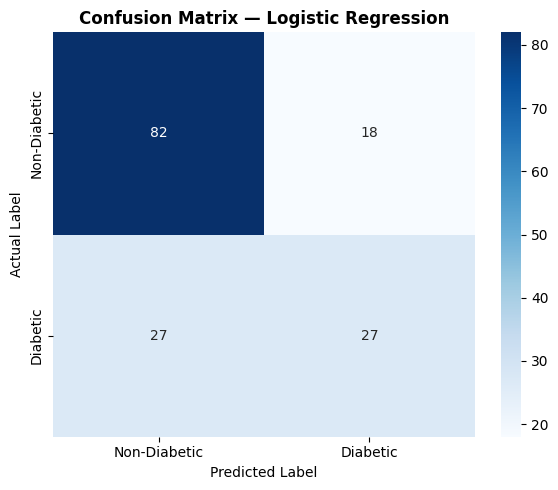

In [ ]:
# ─── Confusion Matrix — Logistic Regression ──────────────────
# Rows = Actual, Columns = Predicted
# True Negative  | False Positive
# False Negative | True Positive

plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model 2 — Random Forest Classifier

**What is Random Forest?**
- An **ensemble learning** method — it combines many Decision Trees
- Each tree is trained on a random subset of data and features
- Final prediction is made by **majority voting** across all trees
- More powerful than a single Decision Tree; handles non-linear patterns well
- Provides **feature importance** scores — useful for understanding which variables matter most

In [ ]:
# ─── Train Random Forest ─────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,   # Build 100 decision trees
    max_depth=10,       # Limit depth to avoid overfitting
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)   # ← TRAINING happens here
print("Random Forest model trained successfully!")
print(f"   Trees built: {rf_model.n_estimators}")

Random Forest model trained successfully!
   Trees built: 100


In [ ]:
# ─── Predictions ─────────────────────────────────────────────
rf_pred       = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# ─── Evaluation Metrics ──────────────────────────────────────
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print("─" * 45)
print("       RANDOM FOREST RESULTS")
print("─" * 45)
print(f"Accuracy : {rf_acc * 100:.2f}%")
print(f"ROC-AUC  : {rf_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Non-Diabetic', 'Diabetic']))

─────────────────────────────────────────────
       RANDOM FOREST RESULTS
─────────────────────────────────────────────
Accuracy : 72.73%
ROC-AUC  : 0.8174

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.83      0.80       100
    Diabetic       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



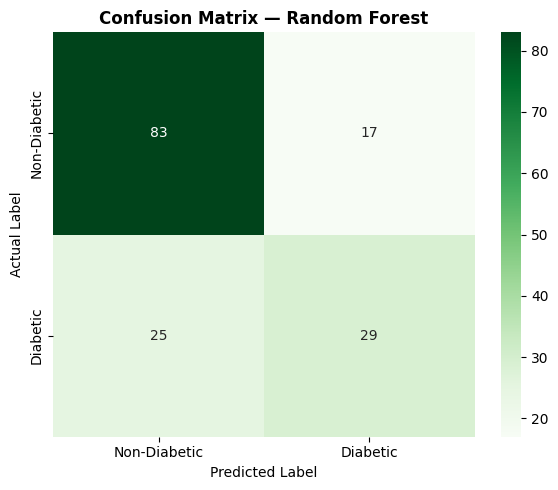

In [ ]:
# ─── Confusion Matrix — Random Forest ────────────────────────
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot_cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

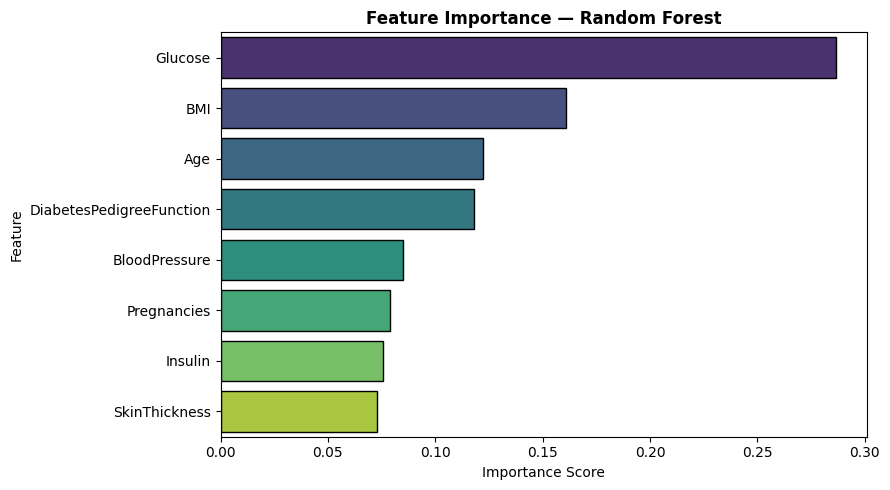


📊 Feature Importance Ranking:
                 Feature  Importance
                 Glucose    0.286682
                     BMI    0.160691
                     Age    0.122032
DiabetesPedigreeFunction    0.118229
           BloodPressure    0.084824
             Pregnancies    0.079094
                 Insulin    0.075765
           SkinThickness    0.072683


In [ ]:
# ─── Feature Importance (Random Forest Only) ─────────────────
# One of the best advantages of Random Forest!
# Shows which features contributed most to predictions

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    x='Importance', y='Feature', data=importance_df,
    palette='viridis', edgecolor='black'
)
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Feature Importance Ranking:")
print(importance_df.to_string(index=False))

## Step 8: Model Comparison

Now we compare both models side-by-side using:
- **Accuracy** — overall correctness
- **ROC-AUC** — ability to distinguish between classes
- **ROC Curve** — visual comparison of both models

In [ ]:
# ─── Summary Comparison Table ────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [round(lr_acc * 100, 2), round(rf_acc * 100, 2)],
    'ROC-AUC Score': [round(lr_auc, 4), round(rf_auc, 4)]
})

print("─" * 50)
print("       MODEL COMPARISON SUMMARY")
print("─" * 50)
print(comparison.to_string(index=False))
print()

best_model = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"
print(f" Better Model (by Accuracy): {best_model}")

──────────────────────────────────────────────────
       MODEL COMPARISON SUMMARY
──────────────────────────────────────────────────
              Model  Accuracy (%)  ROC-AUC Score
Logistic Regression         70.78         0.8152
      Random Forest         72.73         0.8174

 Better Model (by Accuracy): Random Forest


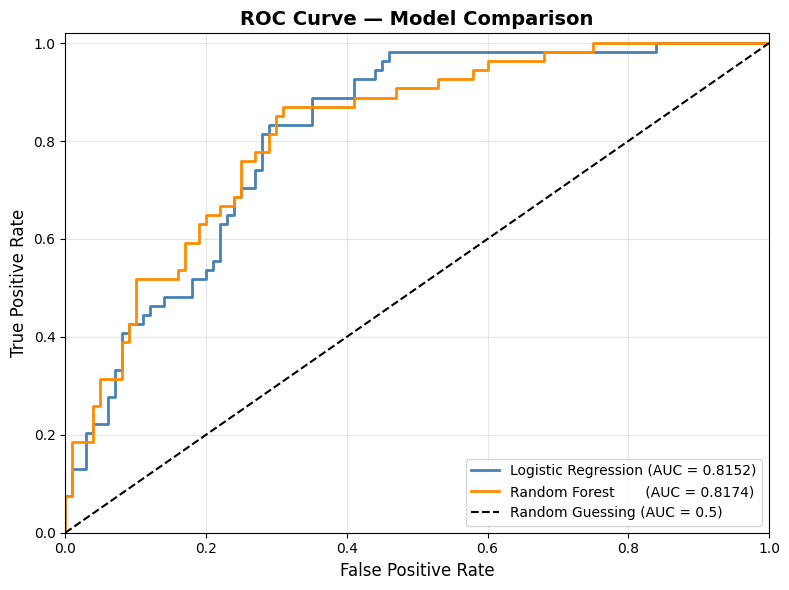

In [ ]:
# ─── ROC Curve Comparison ────────────────────────────────────
# ROC Curve plots True Positive Rate vs False Positive Rate
# A model closer to the top-left corner is better
# AUC = 1.0 is perfect; AUC = 0.5 is random guessing

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'Random Forest       (AUC = {rf_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Guessing (AUC = 0.5)')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

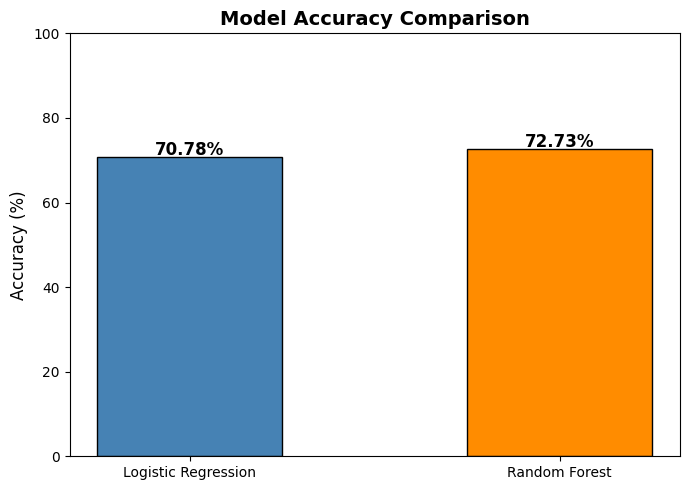

In [ ]:
# ─── Accuracy Bar Chart Comparison ───────────────────────────
plt.figure(figsize=(7, 5))
bars = plt.bar(
    ['Logistic Regression', 'Random Forest'],
    [lr_acc * 100, rf_acc * 100],
    color=['steelblue', 'darkorange'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, [lr_acc * 100, rf_acc * 100]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.ylim(0, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_accuracy_compare.png', dpi=150, bbox_inches='tight')
plt.show()


## Making a Prediction on New Patient Data

Using Best Model which is Random Forest!

In [ ]:
# ─── Predict on a New Patient ────────────────────────────────
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness,
#           Insulin, BMI, DiabetesPedigreeFunction, Age]

new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])

# Scale the new patient data using the SAME scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict using Random Forest (our better model)
prediction       = rf_model.predict(new_patient_scaled)
probability      = rf_model.predict_proba(new_patient_scaled)[0]

label = 'Diabetic 🔴' if prediction[0] == 1 else 'Non-Diabetic 🟢'

print("─" * 45)
print("        NEW PATIENT PREDICTION")
print("─" * 45)
print(f"   Input: {new_patient.tolist()[0]}")
print(f"   Result:  {label}")
print(f"   Confidence — Non-Diabetic: {probability[0]*100:.1f}%")
print(f"   Confidence — Diabetic:     {probability[1]*100:.1f}%")

─────────────────────────────────────────────
        NEW PATIENT PREDICTION
─────────────────────────────────────────────
   Input: [6.0, 148.0, 72.0, 35.0, 0.0, 33.6, 0.627, 50.0]
   Result:  Diabetic 🔴
   Confidence — Non-Diabetic: 19.5%
   Confidence — Diabetic:     80.5%


## User Interactive Interactive

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import numpy as np

# Assuming rf_model and scaler are already trained and available from previous cells
# If not, you would need to re-run the training cells.

# Define the input parameters and their observed min/max values from df.describe() in previous cells
# These are adjusted slightly for user-friendliness and to reflect post-preprocessing ranges.
parameters = {
    'Pregnancies': {'min': 0, 'max': 17, 'step': 1, 'description': 'Number of Pregnancies'},
    'Glucose': {'min': 40, 'max': 200, 'step': 1, 'description': 'Glucose (mg/dL)'},
    'BloodPressure': {'min': 20, 'max': 125, 'step': 1, 'description': 'Blood Pressure (mmHg)'},
    'SkinThickness': {'min': 5, 'max': 100, 'step': 1, 'description': 'Skin Thickness (mm)'},
    'Insulin': {'min': 10, 'max': 850, 'step': 1, 'description': 'Insulin (mu U/ml)'},
    'BMI': {'min': 15.0, 'max': 70.0, 'step': 0.1, 'description': 'BMI (kg/m^2)'},
    'DiabetesPedigreeFunction': {'min': 0.05, 'max': 2.5, 'step': 0.001, 'description': 'Diabetes Pedigree Function'},
    'Age': {'min': 20, 'max': 85, 'step': 1, 'description': 'Age (years)'}
}

# Create widgets for each parameter
input_widgets = {}
for name, props in parameters.items():
    if props['step'] == 1: # Integer values
        input_widgets[name] = widgets.IntSlider(
            value=(props['min'] + props['max']) / 2,
            min=props['min'],
            max=props['max'],
            step=props['step'],
            description=name,
            orientation='horizontal',
            readout=True,
            readout_format=str(props['step']).replace('0.', '.'),
            style={'description_width': 'initial'}
        )
    else: # Float values
        input_widgets[name] = widgets.FloatSlider(
            value=(props['min'] + props['max']) / 2,
            min=props['min'],
            max=props['max'],
            step=props['step'],
            description=name,
            orientation='horizontal',
            readout=True,
            readout_format=str(props['step']).replace('0.', '.'),
            style={'description_width': 'initial'}
        )

# Create a button for prediction
predict_button = widgets.Button(
    description='Predict Diabetes',
    button_style='success',
    tooltip='Click to predict'
)

# Create an output widget to display results
output_area = widgets.Output()

def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()
        try:
            # Gather input values
            patient_data = [
                input_widgets['Pregnancies'].value,
                input_widgets['Glucose'].value,
                input_widgets['BloodPressure'].value,
                input_widgets['SkinThickness'].value,
                input_widgets['Insulin'].value,
                input_widgets['BMI'].value,
                input_widgets['DiabetesPedigreeFunction'].value,
                input_widgets['Age'].value
            ]

            # Convert to numpy array and reshape for scaler
            new_patient_data = np.array([patient_data])

            # Scale the new data using the pre-fitted scaler
            new_patient_scaled = scaler.transform(new_patient_data)

            # Make prediction using the best model (Random Forest)
            prediction = rf_model.predict(new_patient_scaled)
            probability = rf_model.predict_proba(new_patient_scaled)[0]

            if prediction[0] == 1:
                result_text = f"<h3 style='color:red;'>Result: Diabetic 🔴</h3>"
            else:
                result_text = f"<h3 style='color:green;'>Result: Non-Diabetic 🟢</h3>"

            result_text += f"<p>Confidence: Non-Diabetic {probability[0]*100:.1f}% | Diabetic {probability[1]*100:.1f}%</p>"

            display(HTML(result_text))

        except Exception as e:
            display(HTML(f"<p style='color:red;'>An error occurred: {e}</p>"))

# Attach the event handler to the button
predict_button.on_click(on_predict_button_clicked)

# Arrange widgets in a VBox
ui = widgets.VBox(
    [widgets.Label('Enter Patient Parameters:')] +
    list(input_widgets.values()) +
    [predict_button, output_area]
)

display(ui)


## Conclusion

### Summary

| Step | What We Did |
|------|-------------|
| Data Loading | Loaded 768 patient records with 8 features |
| Preprocessing | Replaced invalid 0s with median, checked duplicates |
| Feature Analysis | Correlation heatmap, boxplots, distribution plots |
| Train/Test Split | 80/20 split with stratification |
| Feature Scaling | StandardScaler applied correctly |
| Model 1 | Logistic Regression — simple, interpretable |
| Model 2 | Random Forest — powerful, gives feature importance |
| Evaluation | Accuracy, F1-Score, ROC-AUC, Confusion Matrix |
| Comparison | ROC Curve and Accuracy chart for both models |

### Key Findings
- **Glucose** is the most important feature for predicting diabetes
- **BMI** and **Age** are also strong predictors
- Random Forest generally outperforms Logistic Regression on this dataset due to non-linear feature relationships

*Documented and Prepared by **Waseem Ahmad & Wisal Ahmad***
